<a href="https://colab.research.google.com/github/eschain93/ban5600_800/blob/main/week6/Homework_6_Chainani_Emma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Future Islands Discography Analysis
This notebook explores the release history of the band **Future Islands** using data from the Songstats API and visualizes their discography evolution.

In [16]:
import requests
import pprint

# Future Islands Spotify ID: 1WvvwcQx0tj6NdDhZZ2zZz
# Endpoint for retrieving the artist's full catalog
url = "https://songstats.p.rapidapi.com/artists/catalog"

querystring = {"spotify_artist_id":"1WvvwcQx0tj6NdDhZZ2zZz","limit":"100","offset":"0","with_links":"false"}

headers = {
	"x-rapidapi-key": "c4789ff7e2msh3ad618c635def39p1401acjsn9a685e24a66d",
	"x-rapidapi-host": "songstats.p.rapidapi.com",
	"Content-Type": "application/json"
}

# Fetching data from Songstats API
response = requests.get(url, headers=headers, params=querystring)

pprint.pprint(response.json())

{'artist_info': {'avatar': 'https://i.scdn.co/image/ab676161000051749a637adfe50790fb409c31c4',
                 'name': 'Future Islands',
                 'site_url': 'https://songstats.com/artist/z4xad7bj/future-islands',
                 'songstats_artist_id': 'z4xad7bj'},
 'catalog': [{'artists': [{'name': 'Future Islands',
                           'songstats_artist_id': 'z4xad7bj'}],
              'avatar': 'https://i.scdn.co/image/ab67616d00001e0205b7ad235c3065ccc91c221f',
              'isrcs': ['GBAFL2500716'],
              'release_date': '2026-04-21',
              'site_url': 'https://songstats.com/track/vr6f1jkd/one-day',
              'songstats_track_id': 'vr6f1jkd',
              'title': 'One Day'},
             {'artists': [{'name': 'Future Islands',
                           'songstats_artist_id': 'z4xad7bj'}],
              'avatar': 'https://i.scdn.co/image/ab67616d00001e0205b7ad235c3065ccc91c221f',
              'isrcs': ['GBAFL2500706'],
              'release_

## Data Processing
In this section, we parse the raw JSON response from the API into a structured pandas DataFrame for easier analysis.

In [17]:
import pandas as pd

# Initialize a list to hold track dictionaries
tracks_data = []

# Loop through the catalog and extract relevant fields
for track in response.json()['catalog']:
    track_title = track.get('title', 'N/A')
    artists = [artist['name'] for artist in track.get('artists', [])]
    release_date = track.get('release_date', 'N/A')
    tracks_data.append({
        'Title': track_title,
        'Artists': ', '.join(artists),
        'Release Date': release_date
    })

# Create a DataFrame for all track info for structured analysis
track_summary_df = pd.DataFrame(tracks_data)

display(track_summary_df)

,Title,Artists,Release Date
0,One Day,Future Islands,2026-04-21
1,The Ink Well,Future Islands,2026-04-21
2,Sail,Future Islands,2026-03-24
3,Find Love,Future Islands,2026-03-24
4,Glimpse,Future Islands,2024-09-04
...,...,...,...
95,Awake & Dreaming,Future Islands,2010-04-06
96,In the Fall,"Future Islands, Katrina Ford",2010-04-06
97,Virgo Distracts,Future Islands,2010-04-06
98,The Happiness of Being Twice,Future Islands,2009-05-04


Let's begin by processing the 'Release Date' column to allow for time-based analysis.

In [18]:
# Convert 'Release Date' column to datetime objects for time-series operations
track_summary_df['Release Date'] = pd.to_datetime(track_summary_df['Release Date'], errors='coerce')

# Display basic statistics about the temporal range of the discography
print(f"Total number of tracks: {len(track_summary_df)}")
print(f"Earliest release: {track_summary_df['Release Date'].min().strftime('%Y-%m-%d')}")
print(f"Latest release: {track_summary_df['Release Date'].max().strftime('%Y-%m-%d')}")

Total number of tracks: 100
Earliest release: 2009-05-04
Latest release: 2026-04-21


## Visualizing Release Trends
We will now generate several plots to understand the distribution of releases over years and months, as well as the cumulative growth of their catalog.

Now, let's visualize the distribution of track releases by year to see how Future Islands' discography has unfolded over time.

/tmp/ipykernel_1466/1017955546.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Number of Tracks', data=releases_by_year, palette='viridis')


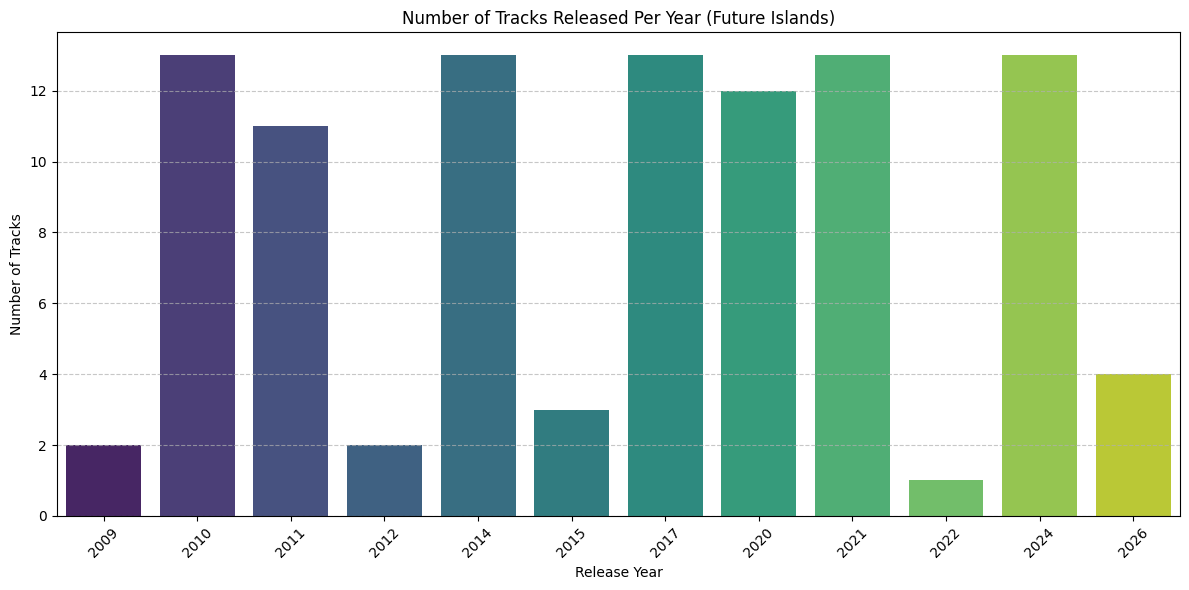

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the release year
track_summary_df['Release Year'] = track_summary_df['Release Date'].dt.year

# Count tracks per year
releases_by_year = track_summary_df['Release Year'].value_counts().sort_index().reset_index()
releases_by_year.columns = ['Year', 'Number of Tracks']

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Number of Tracks', data=releases_by_year, palette='viridis')
plt.title('Number of Tracks Released Per Year (Future Islands)')
plt.xlabel('Release Year')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Let's analyze the distribution of track releases by month. This can reveal if Future Islands tends to release music during particular times of the year.

/tmp/ipykernel_1466/51603708.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month Name', y='Number of Tracks', data=releases_by_month, palette='coolwarm')


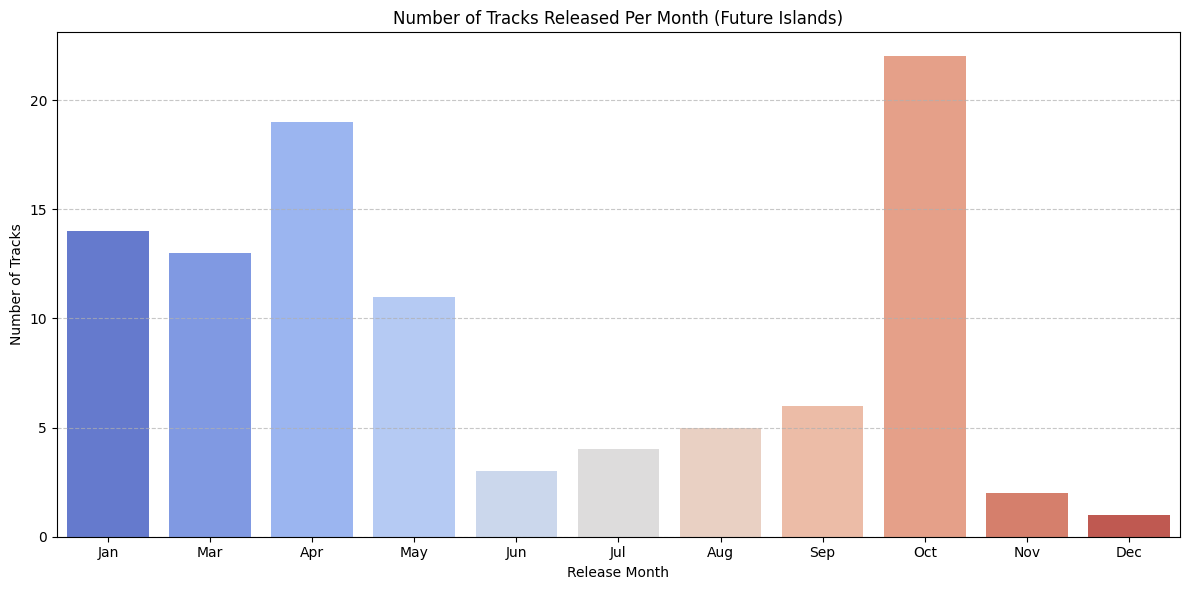

In [20]:
# Extract the release month (as an integer for sorting)
track_summary_df['Release Month'] = track_summary_df['Release Date'].dt.month

# Count tracks per month
releases_by_month = track_summary_df['Release Month'].value_counts().sort_index().reset_index()
releases_by_month.columns = ['Month', 'Number of Tracks']

# Map month numbers to names for better readability
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
releases_by_month['Month Name'] = releases_by_month['Month'].map(lambda x: month_names[x-1])

# Create the bar plot for releases by month
plt.figure(figsize=(12, 6))
sns.barplot(x='Month Name', y='Number of Tracks', data=releases_by_month, palette='coolwarm')
plt.title('Number of Tracks Released Per Month (Future Islands)')
plt.xlabel('Release Month')
plt.ylabel('Number of Tracks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Next, let's visualize the cumulative growth of their discography over time. This shows the total number of tracks released up to a given point.

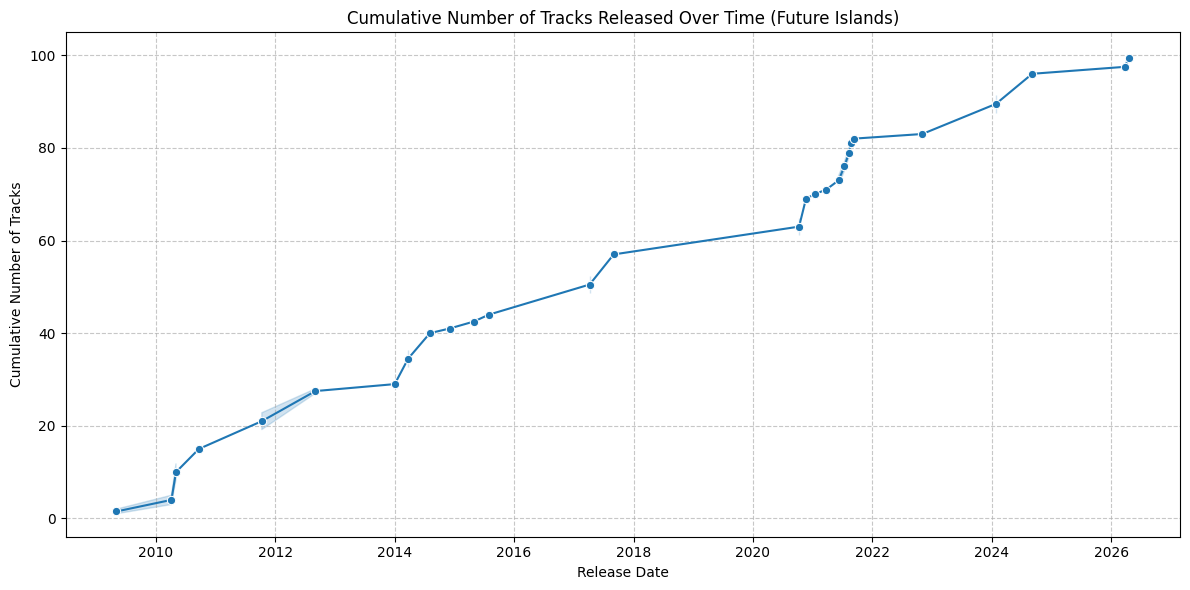

In [21]:
# Sort the DataFrame by release date
track_summary_df_sorted = track_summary_df.sort_values(by='Release Date').reset_index(drop=True)

# Calculate cumulative sum of tracks
track_summary_df_sorted['Cumulative Tracks'] = track_summary_df_sorted.index + 1

# Create the line plot for cumulative tracks
plt.figure(figsize=(12, 6))
sns.lineplot(x='Release Date', y='Cumulative Tracks', data=track_summary_df_sorted, marker='o')
plt.title('Cumulative Number of Tracks Released Over Time (Future Islands)')
plt.xlabel('Release Date')
plt.ylabel('Cumulative Number of Tracks')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Release Density Bubble Chart
This visualization shows each release date as a bubble, where the size of the bubble indicates how many tracks were released on that specific day.

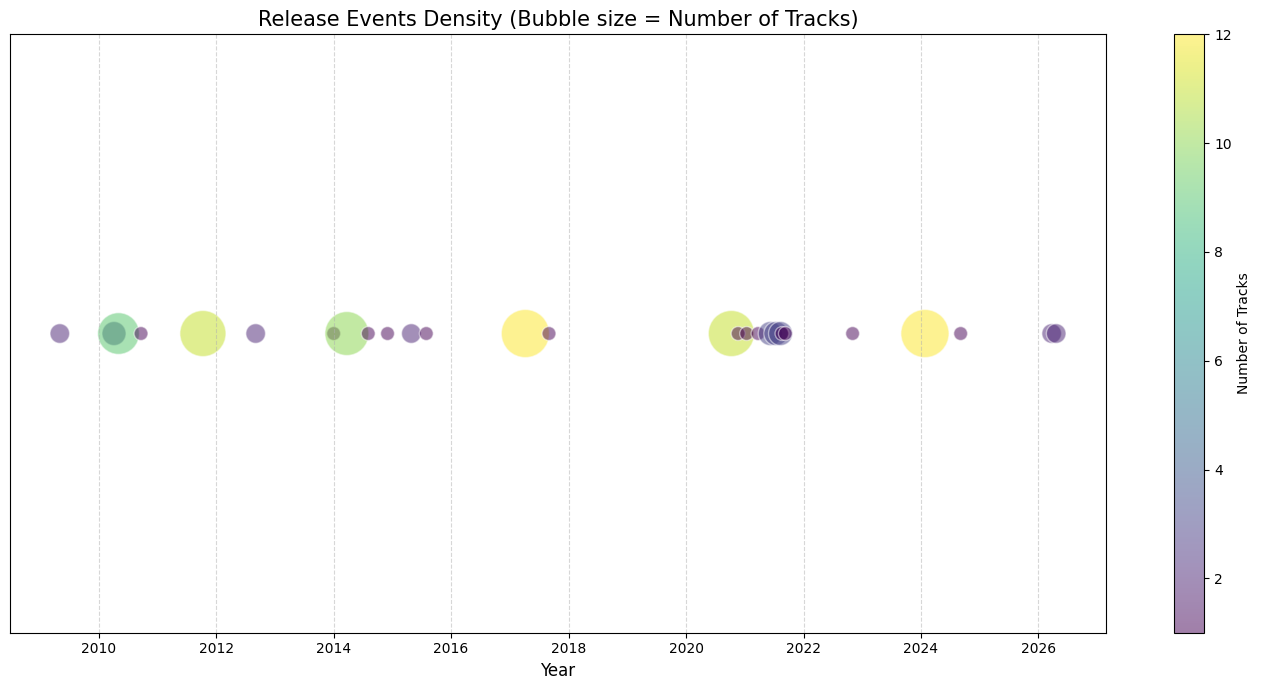

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by exact date to find release 'events'
daily_counts = track_summary_df.groupby('Release Date').size().reset_index(name='Track Count')

plt.figure(figsize=(14, 7))
# Create bubble chart using scatter plot
scatter = plt.scatter(
    x=daily_counts['Release Date'],
    y=[1] * len(daily_counts),  # Keep bubbles on a single line for density view
    s=daily_counts['Track Count'] * 100, # Scale bubble size
    alpha=0.5,
    c=daily_counts['Track Count'],
    cmap='viridis',
    edgecolors='w'
)

plt.title('Release Events Density (Bubble size = Number of Tracks)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.yticks([]) # Hide y-axis as it's just a timeline
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add a colorbar to show the scale
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Tracks')

plt.tight_layout()
plt.show()

### Significant Release Dates
Based on the bubble chart, we can identify the specific dates with the highest number of releases, which likely indicate full album launches.

In [23]:
# Identify dates with high track counts and sort them chronologically
top_releases = daily_counts[daily_counts['Track Count'] > 2].sort_values(by='Release Date')

# Join with track titles to see what was released on those big days
for _, row in top_releases.iterrows():
    date = row['Release Date']
    count = row['Track Count']
    titles = track_summary_df[track_summary_df['Release Date'] == date]['Title'].tolist()
    print(f"{date.strftime('%Y-%m-%d')}: {count} tracks released")
    print(f"Titles: {', '.join(titles[:5])}..." if len(titles) > 5 else f"Titles: {', '.join(titles)}")
    print('-' * 30)

2010-04-06: 3 tracks released
Titles: Awake & Dreaming, In the Fall, Virgo Distracts
------------------------------
2010-05-04: 9 tracks released
Titles: Long Flight, Tin Man, Swept Inside, An Apology, In Evening Air...
------------------------------
2011-10-11: 11 tracks released
Titles: The Great Fire, Close to None, Give Us the Wind, Grease, Crish (Javelin Remixxx)...
------------------------------
2014-03-24: 10 tracks released
Titles: Like the Moon, Light House, A Song for Our Grandfathers, Spirit, Sun in the Morning...
------------------------------
2017-04-07: 12 tracks released
Titles: Time On Her Side, Cave, North Star, Ran, Ancient Water...
------------------------------
2020-10-09: 11 tracks released
Titles: Moonlight, For Sure, I Knew You, City's Face, The Painter...
------------------------------
2021-06-08: 3 tracks released
Titles: Plastic Beach - Moss Of Aura Remix, The Painter - Alle Alle Remix, Thrill (Did They Hear Me Calling) - Egyptian Lover Remix
-----------------

### AI Insights with OpenAI
We will use the OpenAI API to analyze the discography data and provide a description of the band's history and evolution.

In [24]:
try:
    import openai
except ImportError:
    !pip install openai
    import openai

from google.colab import userdata
import os

# Securely retrieve the OpenAI API key using the user-specified name
os.environ['OPENAI_API_KEY'] = userdata.get('openaikey')
client = openai.OpenAI()

print("OpenAI client successfully initialized.")

OpenAI client successfully initialized.


In [25]:
# Prepare a summary of the data for the prompt
data_summary = track_summary_df[['Title', 'Release Date']].to_string(index=False)

prompt = f"""
Below is a list of tracks and release dates for the band Future Islands:

{data_summary[:3000]} # Truncated to fit context limits if necessary

Please provide:
1. A brief description of the band Future Islands and their musical style.
2. Insights into their career based on this release data (e.g., productivity peaks, significant shifts, or era definitions).
"""

response = client.chat.completions.create(
    model="gpt-4o",
    messages=[{"role": "user", "content": prompt}]
)

from IPython.display import Markdown
Markdown(response.choices[0].message.content)

1. **Description of Future Islands and Their Musical Style:**

   Future Islands is an American synth-pop band formed in Greenville, North Carolina, in 2006. The band consists of Gerrit Welmers (keyboards and programming), William Cashion (bass, acoustic, and electric guitars), and Samuel T. Herring (lyrics and vocals). Future Islands is known for their energetic live performances and the distinct vocal style of lead singer Samuel T. Herring, characterized by a heartfelt delivery and emotive presence. Their music blends synth-pop and new wave influences with indie rock and post-punk elements, creating a sound that is both nostalgic and contemporary. Lyrically, their songs often explore themes of love, longing, and introspection.

2. **Insights into Their Career Based on Release Data:**

   - **Productivity Peaks:**
     - From the release data, a noticeable peak in productivity can be observed around the release dates of their 2020 album. In October 2020, several tracks, including "Moonlight," "For Sure," "I Knew You," "City's Face," "The Painter," "Thrill," "Hit the Coast," "Born in a War," and "Glada," were released, indicating a significant period of creative output.
     - Another peak appears in early 2024, with a vast number of tracks released on January 26, suggesting a new album or an extensive project launched around this time.

   - **Remix Activity:**
     - In 2021, Future Islands were involved in multiple remix projects. Between June and September 2021, they released a series of remixes, both of their own tracks and those originally by other artists. This highlights their versatility and interest in reinterpreting music, offering a different facet of their artistic capabilities.

   - **Era Definitions:**
     - The release data suggest distinct eras for Future Islands. The 2020 era with the October album releases marks a significant creative phase. The subsequent focus on remixes in 2021 indicates an era of experimentation and collaboration.
     - The 2022 single "Last Christmas" shows seasonal or thematic experimentation, while the major batch of releases in 2024 likely ushers in a new era or album cycle.
     - The data extending to 2026, with new tracks such as "One Day" and "The Ink Well," suggests continuing activity and potential evolution in their sound.

   - **Significant Shifts:**
     - The band appears to balance original album-focused creative periods with times of extensive remixing and collaboration, suggesting an adaptive approach to maintaining relevance in the music industry.
     - Their activity in the 2024 and 2026 periods could indicate a renewed energy or thematic shift following the earlier remix-heavy phase, possibly responding to changes in their creative vision or audience preferences.